In [1]:
import sys
sys.path.append("src")

## Generate example codes

In [2]:
from gentoriccode import *

In [3]:
tc5 = GTCode(v1=[10,0], 
               v2=[0,10], 
               basis='Z',
               fpoly=[[0,0],[1,0]],
               gpoly=[[0,0],[0,1]],
               pphys=0.001,
               addwidth=0) # d=5 toric code

100 points in parallelogram
Initialized STIM circuit
Added parity check matrices
<Unnamed CSS code>
 -Block dimensions: Pass
 -PCMs commute hz@hx.T==0: Pass
 -PCMs commute hx@hz.T==0: Pass
 -lx \in ker{hz} AND lz \in ker{hx}: Pass
 -lx and lz anticommute: Pass
 -<Unnamed CSS code> is a valid CSS code w/ params [50,2,nan]
Extracted Z symmetries:  1 symmetries of lengths [25.]
Added v  logical for sym 0
We DO NOT have a generating set of logicals yet.
Added h  logical for sym 0
We have a generating set of logicals
The shortest logical operator is:  5


In [4]:
neen120 = GTCode(v1=[30,0], 
               v2=[6,8], 
               basis='Z',
               fpoly=[[0,0],[3,-1]],
               gpoly=[[0,0],[1,0],[2,0]],
               pphys=0.001,
               addwidth=-0.5) # this code was supposed to have distance 8 

240 points in parallelogram
Initialized STIM circuit
Added parity check matrices
<Unnamed CSS code>
 -Block dimensions: Pass
 -PCMs commute hz@hx.T==0: Pass
 -PCMs commute hx@hz.T==0: Pass
 -lx \in ker{hz} AND lz \in ker{hx}: Pass
 -lx and lz anticommute: Pass
 -<Unnamed CSS code> is a valid CSS code w/ params [120,4,nan]
Extracted Z symmetries:  2 symmetries of lengths [40.]
Added v  logical for sym 0
Added v  logical for sym 1
We DO NOT have a generating set of logicals yet.
Added h  logical for sym 0
Added h  logical for sym 1
We have a generating set of logicals
The shortest logical operator is:  4


In [5]:
# also import code from code_pickles folder for quick creation
import pickle

with open(f"code_pickles/bb144.pkl", 'rb') as f:  
        bb144 = pickle.load(f) 

## Prepare symatch object

In [6]:
from symatch_prep import SyMatch

Test: Importing symatch_prep


In [7]:
# create a decoder for the d=5 toric code. this instance will reduce to basic matching
sm_tc5 = SyMatch(tc5, tc5.circ.detector_error_model(), bp=False, predecode=False, simplex=False)

In [8]:
#test decoding trivial syndrome
sm_tc5.decode(np.zeros(25))

[np.int64(0), np.int64(0)]

## Sample with sinter and plot result

In [9]:
from sinter_run import sinter_collect 

In [10]:
bb144_samples = sinter_collect(bb144, 2000, bpparams=[0,1], simplexparams=[0])

Starting 1 workers...
10 tasks left:
  workers              decoder eta shots_left errors_left json_metadata                     
        1 symatch144_bp0_smpl0 <1m       1999          40 p=0.01,code=144-12,d=12,k=12,n=144
        0 symatch144_bp1_smpl0 ?·∞       2000          40 p=0.01,code=144-12,d=12,k=12,n=144
        0 symatch144_bp0_smpl0 ?·∞       2000          40 p=0.02,code=144-12,d=12,k=12,n=144
        0 symatch144_bp1_smpl0 ?·∞       2000          40 p=0.02,code=144-12,d=12,k=12,n=144
        0 symatch144_bp0_smpl0 ?·∞       2000          40 p=0.04,code=144-12,d=12,k=12,n=144
        0 symatch144_bp1_smpl0 ?·∞       2000          40 p=0.04,code=144-12,d=12,k=12,n=144
        0 symatch144_bp0_smpl0 ?·∞       2000          40 p=0.08,code=144-12,d=12,k=12,n=144
        0 symatch144_bp1_smpl0 ?·∞       2000          40 p=0.08,code=144-12,d=12,k=12,n=144
        0 symatch144_bp0_smpl0 ?·∞       2000          40 p=0.1,code=144-12,d=12,k=12,n=144 
        0 symatch144_bp1_smpl0 ?·

Text(0, 0.5, 'Logical error rate')

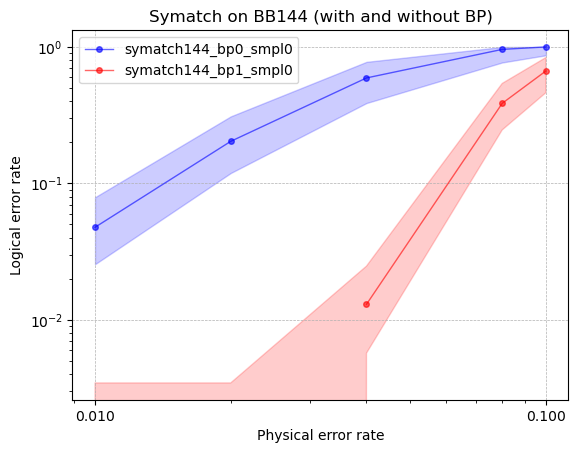

In [12]:
import matplotlib.pyplot as plt
import sinter
import matplotlib as mpl
from cycler import cycler
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

fig, ax = plt.subplots(
    nrows = 1,
    ncols = 1
)

##### Plot logical error rate vs expected attempts ####
sinter.plot_error_rate(
    ax = ax,
    stats = bb144_samples,
    filter_func = lambda stats: True,
    group_func = lambda stats: f'{stats.decoder}', #label
    x_func = lambda stats: np.round(stats.json_metadata['p'], 6),
    plot_args_func = lambda _, label: {
        'color' : 'blue' if 'bp0' in label else 'red',
        'marker' : 'o',
        'markersize' : 4,
        'linewidth' : 1,
        'linestyle': '-',
        'alpha': 0.6 if 'smpl0' in label else 1
    },
    )

ax.loglog()
ax.legend()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.grid(which='major', linestyle = '--', lw = 0.5)
ax.set_title('Symatch on BB144 (with and without BP)')
ax.set_xlabel('Physical error rate')    
ax.set_ylabel('Logical error rate')